# PFA ALSA — Prevision de la demande voyageurs
Pipeline complet : chargement, EDA, feature engineering, LSTM, comparaison de modeles, interpretation.

**A faire avant de lancer** : uploader `BD_EXPLOITATION_clean.csv` dans votre Drive et adapter `DATA_PATH`.

In [1]:
# Installation des librairies
!pip install -q statsmodels xgboost

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

MODELS_DIR = '/content/drive/MyDrive/alsa_pfa_corrige/models'

In [3]:
import os

MODELS_DIR = "/content/drive/MyDrive/alsa_pfa_corrige/models"

print(os.listdir(MODELS_DIR))

['lstm_bus_direct_ligne12.keras', 'lstm_global_toutes_lignes.keras', 'scalers_par_ligne.pkl', 'lignes_modele_global.pkl', 'lstm_ligne12.keras', 'scaler_ligne12.pkl', 'scaler_bus_ligne12.pkl', 'lstm_bus_ligne12.keras', 'lstm_ligne_1.keras', 'lstm_bus_ligne_1.keras', 'scaler_ligne_1.pkl', 'scaler_bus_ligne_1.pkl', 'lstm_ligne_10.keras', 'lstm_bus_ligne_10.keras', 'scaler_ligne_10.pkl', 'scaler_bus_ligne_10.pkl', 'lstm_bus_ligne_11.keras', 'lstm_ligne_11.keras', 'scaler_ligne_11.pkl', 'scaler_bus_ligne_11.pkl', 'lstm_ligne_12.keras', 'lstm_bus_ligne_12.keras', 'scaler_ligne_12.pkl', 'scaler_bus_ligne_12.pkl', 'lstm_ligne_13.keras', 'lstm_bus_ligne_13.keras', 'scaler_ligne_13.pkl', 'scaler_bus_ligne_13.pkl', 'lstm_bus_ligne_14.keras', 'lstm_ligne_14.keras', 'scaler_ligne_14.pkl', 'scaler_bus_ligne_14.pkl', 'lstm_ligne_15.keras', 'lstm_bus_ligne_15.keras', 'scaler_ligne_15.pkl', 'scaler_bus_ligne_15.pkl', 'lstm_ligne_16.keras', 'lstm_bus_ligne_16.keras', 'scaler_ligne_16.pkl', 'scaler_bus_l

## 1. Chargement et nettoyage des donnees brutes
On part directement du fichier Excel original (`BD_EXPLOITATION.xlsx`, onglet `BD`) pour que le nettoyage soit trace et reproductible dans le rapport.

In [4]:
RAW_PATH = '/content/drive/MyDrive/alsa_pfa_corrige/data/raw/BD EXPLOITATION(ESSAI).xlsx'
CLEAN_PATH = '/content/drive/MyDrive/alsa_pfa_corrige/data/processed/BD_EXPLOITATION_clean.csv'

cols = ['date','ligne','passagers','billets','ikhlas','transfert','ikhlas_transfert',
        'etudiants','recette','bus','km','type_jour','type_ligne','horas']

raw = pd.read_excel(RAW_PATH, sheet_name='BD', usecols=range(len(cols)), header=0, names=cols)
raw['date'] = pd.to_datetime(raw['date'])
raw['ligne'] = raw['ligne'].astype(str)

print('Shape brute :', raw.shape)

Shape brute : (49136, 14)


In [5]:
# --- Etapes de nettoyage ---

# 1) lignes sans identifiant de ligne (valeur manquante)
df = raw.dropna(subset=['ligne']).copy()

# 2) doublons date+ligne (on garde la premiere occurrence)
nb_doublons = df.duplicated(subset=['date','ligne']).sum()
df = df.drop_duplicates(subset=['date','ligne'], keep='first')
print(f'Doublons date+ligne supprimes : {nb_doublons}')

# 3) lignes jamais frequentees (0 passager sur toute la periode) -> inactives, on les exclut
totaux = df.groupby('ligne')['passagers'].sum()
lignes_inactives = totaux[totaux == 0].index.tolist()
print('Lignes inactives exclues :', lignes_inactives)

# 4) lignes a exclure manuellement :
#    22 (remplacee par le BHNS), 28, TVM, navette speciale, transport personnel,
#    ligne evenementielle Timitar, et le BHNS lui-meme (donnees encore trop recentes/instables)
lignes_exclusion_manuelle = ['22', '28', '352', 'TVM', '357- NAVETTE SPECIALE',
                             'TRANSPORT PERSONNEL 362', 'SP- TIMITAR -355', 'BHNS']
lignes_a_exclure = list(set(lignes_inactives + lignes_exclusion_manuelle))
df = df[~df['ligne'].isin(lignes_a_exclure)]

# 5) on coupe le dataset a la derniere date ou on a reellement des donnees
#    (au-dela, ce sont des lignes calendaires vides deja preformatees dans le fichier)
somme_par_jour = df.groupby('date')['passagers'].sum()
derniere_date_reelle = somme_par_jour[somme_par_jour > 0].index.max()
df = df[df['date'] <= derniere_date_reelle]

df = df.sort_values(['ligne','date']).reset_index(drop=True)

print('Shape apres nettoyage :', df.shape)
print('Nb lignes actives conservees :', df['ligne'].nunique())
print('Periode :', df['date'].min(), '->', df['date'].max())

Doublons date+ligne supprimes : 2
Lignes inactives exclues : ['07-72', '18', '19', '25', '34', '352', '4', '81', 'TVM', 'nan']
Shape apres nettoyage : (35148, 14)
Nb lignes actives conservees : 38
Periode : 2024-01-01 00:00:00 -> 2026-07-14 00:00:00


In [6]:
# Sauvegarde du CSV nettoye, reutilisable directement (evite de refaire le nettoyage a chaque fois)
import os
os.makedirs(os.path.dirname(CLEAN_PATH), exist_ok=True)
df.to_csv(CLEAN_PATH, index=False)
df.head()

,date,ligne,passagers,billets,ikhlas,transfert,ikhlas_transfert,etudiants,recette,bus,km,type_jour,type_ligne,horas
0,2024-01-01,1,0,0,0,0,0,0,0.0,0.0,0.000,LV,URB,0.000000
1,2024-01-02,1,700,255,126,48,174,267,1255.0,1.0,132.904,LV,URB,10.516667
2,2024-01-03,1,655,189,115,45,160,303,1087.0,1.0,132.904,LV,URB,10.516667
3,2024-01-04,1,731,167,123,44,167,387,916.0,1.0,132.904,LV,URB,10.516667
4,2024-01-05,1,604,126,99,55,154,318,778.0,1.0,132.904,LV,URB,10.516667


**Choix de la ligne de reference** : la ligne 12 (grande ligne urbaine, bien fournie en donnees). Elle sert a illustrer l'EDA, a caler les hyperparametres (Optuna) et a comparer les modeles (section 6) ; le LSTM final (section 8) est ensuite applique a TOUTES les lignes, pas seulement celle-ci.

In [7]:
LIGNE_REFERENCE = '12'   # a changer pour tester une autre ligne

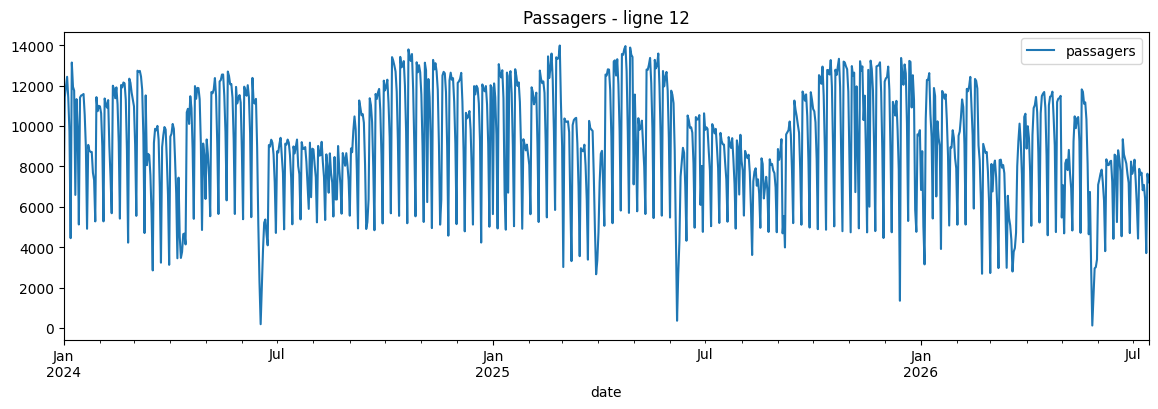

In [8]:
def preparer_serie(df, ligne):
    """Isole une ligne, la met en frequence journaliere continue, interpole les trous,
    et applique la regle metier de la ligne 73 (a l'arret en juillet-aout)."""
    colonnes_utiles = ['passagers', 'type_jour', 'type_ligne', 'bus', 'horas']
    s = df[df['ligne'] == ligne].sort_values('date').set_index('date')[colonnes_utiles]
    s = s.asfreq('D')
    s['passagers'] = s['passagers'].interpolate(method='time')
    s['type_ligne'] = s['type_ligne'].ffill().bfill()
    s['type_jour'] = s['type_jour'].fillna('LV')
    s['bus'] = s['bus'].interpolate(method='time')
    s['horas'] = s['horas'].interpolate(method='time')
    if str(ligne) == '73':
        s = s[~s.index.month.isin([7, 8])]
    return s

# Selection de la ligne de reference et mise en serie temporelle continue (un point par jour)
serie = preparer_serie(df, LIGNE_REFERENCE)
serie[['passagers']].plot(figsize=(14,4), title=f'Passagers - ligne {LIGNE_REFERENCE}')
plt.show()

In [9]:
h = preparer_serie(df, LIGNE_REFERENCE)
print("NaN dans 'bus' :", h['bus'].isna().sum())
print("NaN dans 'horas' :", h['horas'].isna().sum())

NaN dans 'bus' : 0
NaN dans 'horas' : 0


## 2. EDA rapide

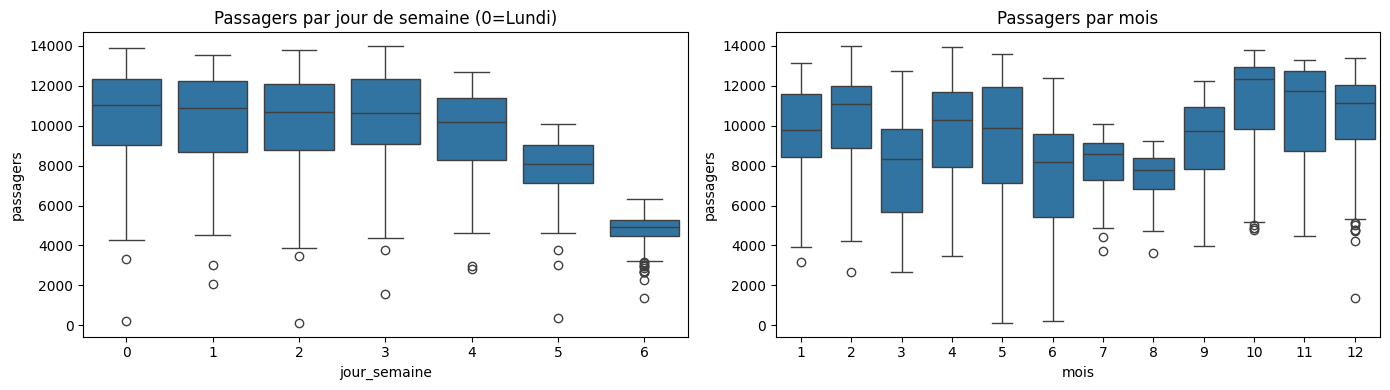

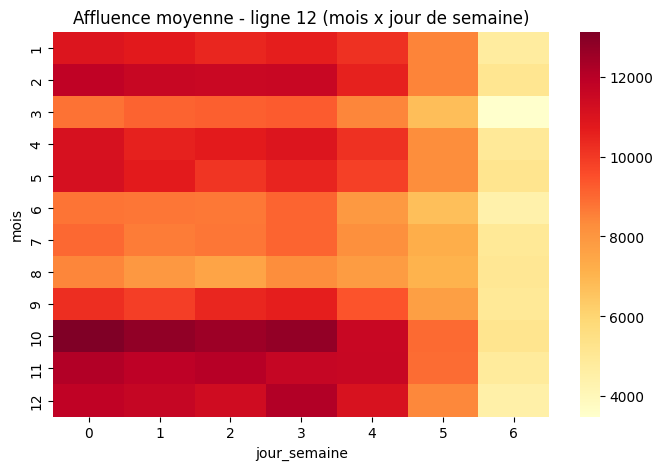

In [10]:
# Distribution par jour de semaine et par mois
tmp = serie.copy()
tmp['jour_semaine'] = tmp.index.dayofweek   # 0=lundi ... 6=dimanche
tmp['mois'] = tmp.index.month

fig, axes = plt.subplots(1, 2, figsize=(14,4))
sns.boxplot(x='jour_semaine', y='passagers', data=tmp, ax=axes[0])
axes[0].set_title('Passagers par jour de semaine (0=Lundi)')
sns.boxplot(x='mois', y='passagers', data=tmp, ax=axes[1])
axes[1].set_title('Passagers par mois')
plt.tight_layout(); plt.show()

# Heatmap mois x jour de semaine (utile pour identifier les periodes de forte/faible affluence)
pivot = tmp.pivot_table(index='mois', columns='jour_semaine', values='passagers', aggfunc='mean')
plt.figure(figsize=(8,5))
sns.heatmap(pivot, cmap='YlOrRd', annot=False)
plt.title(f'Affluence moyenne - ligne {LIGNE_REFERENCE} (mois x jour de semaine)')
plt.show()

## 3. Feature engineering

### 3.1 Calendrier des jours feries marocains
En plus de `is_vacances` (deduite de `type_jour == 'OTROS'`), on ajoute le calendrier officiel des jours feries marocains. On separe :
- `is_aid` : specifiquement l'Aid al-Fitr et l'Aid al-Adha (2 jours chacun), qui provoquent historiquement la plus forte baisse d'affluence (deplacements familiaux, exode des villes) ;
- `is_ferie` : les autres jours feries (fetes civiles + Aid Al Mawlid + 1er Moharram).

**A mettre a jour chaque annee** : les fetes religieuses suivent le calendrier lunaire et sont annoncees par le ministere des Habous seulement quelques jours a l'avance ; les dates ci-dessous sont deja connues/confirmees pour 2024-2026, il faudra ajouter 2027 le moment venu.

In [11]:
# Fetes religieuses a dates variables (calendrier lunaire), confirmees par le ministere des Habous
DATES_AID = [
    # Aid al-Fitr (fin du Ramadan)
    '2024-04-10', '2024-04-11',
    '2025-03-31', '2025-04-01',
    '2026-03-20', '2026-03-21',
    # Aid al-Adha (fete du sacrifice)
    '2024-06-17', '2024-06-18',
    '2025-06-06', '2025-06-07',
    '2026-05-27', '2026-05-28',
]

DATES_AUTRES_FERIES_RELIGIEUX = [
    '2024-07-07',   # 1er Moharram 1446
    '2024-09-16',   # Aid Al Mawlid 1446
    '2025-06-27',   # 1er Moharram 1447
    '2025-09-05',   # Aid Al Mawlid 1447
    '2026-06-17',   # 1er Moharram 1448
    '2026-08-26',   # Aid Al Mawlid 1448
]

# Fetes civiles a dates fixes (memes jours chaque annee)
JOURS_FERIES_FIXES = [(1,1), (1,11), (1,14), (5,1), (7,30), (8,14), (8,20), (8,21), (11,6), (11,18)]

ANNEES_COUVERTES = [2024, 2025, 2026]
dates_feries_fixes = [pd.Timestamp(annee, mois, jour)
                      for annee in ANNEES_COUVERTES for (mois, jour) in JOURS_FERIES_FIXES]

SET_DATES_AID = set(pd.to_datetime(DATES_AID))
SET_DATES_FERIES = set(pd.to_datetime(DATES_AUTRES_FERIES_RELIGIEUX)) | set(dates_feries_fixes)

print(f'{len(SET_DATES_AID)} jours d ete/Aid, {len(SET_DATES_FERIES)} autres jours feries repertories.')

12 jours d ete/Aid, 36 autres jours feries repertories.


In [12]:
# Declaration manuelle : permet a l'utilisateur de marquer un jour comme Aid meme s'il n'est
# pas (encore) dans le calendrier code en dur ci-dessus (utile pour une annee future, ex. 2027,
# ou pour corriger/confirmer une date). Ce jour sera alors traite exactement comme un jour
# d'Aid connu par le modele (is_eid=1)
JOURS_AID_DECLARES = set()

def declarer_jour_aid(date):
    """A appeler pour marquer une date comme jour de l'Aid (ex: declarer_jour_aid('2027-03-10'))."""
    d = pd.Timestamp(date).normalize()
    JOURS_AID_DECLARES.add(d)
    print(f"{d.date()} declare comme jour de l'Aid.")

def annuler_declaration_aid(date):
    """Retire une date declaree par erreur."""
    JOURS_AID_DECLARES.discard(pd.Timestamp(date).normalize())

def est_jour_ferie(date):
    d = date.normalize()
    return (d in SET_DATES_AID) or (d in SET_DATES_FERIES) or (d in JOURS_AID_DECLARES)

def est_jour_aid(date):
    d = date.normalize()
    return (d in SET_DATES_AID) or (d in JOURS_AID_DECLARES)

In [13]:
# Exemple d'utilisation : declarer un jour d'Aid futur non encore dans le calendrier code en dur
# (ex. 2027, dates annoncees seulement quelques jours a l'avance par le ministere des Habous).
declarer_jour_aid('2027-03-10')
print('Bien reconnu comme jour de l\'Aid :', est_jour_aid(pd.Timestamp('2027-03-10')))

annuler_declaration_aid('2027-03-10')  # on annule cet exemple pour ne pas fausser la suite du notebook

2027-03-10 declare comme jour de l'Aid.
Bien reconnu comme jour de l'Aid : True


In [14]:
def add_features(s):
    d = s.copy()
    d['jour_semaine'] = d.index.dayofweek   # 0=lundi ... 6=dimanche
    d['mois'] = d.index.month

    # jours feries (civils + Aid El Fitr/Aid El Adha) : forte baisse d'activite attendue
    d['is_ferie'] = [int(est_jour_ferie(dt)) for dt in d.index]
    d['is_eid'] = [int(est_jour_aid(dt)) for dt in d.index]

    # OTROS = vacances scolaires : comportement different meme un jour de semaine normal
    d['is_vacances'] = (d['type_jour'] == 'OTROS').astype(int)

    # Un jour ferie (JF fixe ou Aid) se comporte comme un dimanche, quel que soit le vrai jour
    # de la semaine ce jour-la (ex. un jeudi ferie se vide comme un dimanche, pas comme un jeudi).
    # On force donc l'encodage du jour de la semaine sur 'dimanche' (6) pour ces dates, et on
    # aligne is_weekend en consequence. is_ferie/is_eid restent en plus, pour que le modele
    # puisse apprendre une baisse encore plus marquee que celle d'un dimanche ordinaire
    # (frequent pour l'Aid, ou l'activite peut etre plus faible qu'un dimanche normal).
    jour_semaine_ajuste = d['jour_semaine'].where(d['is_ferie'] == 0, 6)
    d['is_weekend'] = np.where(d['is_ferie'] == 1, 1, (d['jour_semaine'] >= 5).astype(int))

    # comportement propre a chaque jour (lundi different de mardi, different du weekend...)
    # -> one-hot explicite plutot qu'un simple sin/cos, qui suppose une transition lisse entre jours
    dummies_jour = pd.get_dummies(jour_semaine_ajuste, prefix='jour').astype(int)
    for i in range(7):
        col = f'jour_{i}'
        if col not in dummies_jour:
            dummies_jour[col] = 0
    d = pd.concat([d, dummies_jour], axis=1)

    # saisonnalite mensuelle : encodage cyclique (le mois, lui, varie de facon lisse/continue)
    d['sin_mois'] = np.sin(2*np.pi*d['mois']/12)
    d['cos_mois'] = np.cos(2*np.pi*d['mois']/12)

    # lags courts
    d['lag_1'] = d['passagers'].shift(1)
    d['lag_7'] = d['passagers'].shift(7)
    d['rolling_mean_7'] = d['passagers'].shift(1).rolling(7).mean()
    d['rolling_mean_30'] = d['passagers'].shift(1).rolling(30).mean()

    # comportement du meme jour les annees precedentes (meme jour l'an dernier / il y a 2 ans)
    # NB: avec ~2.5 ans d'historique, le lag a 2 ans n'existe que sur les derniers mois
    # -> on utilise le lag a 1 an comme valeur de repli pour ne pas perdre trop de lignes
    d['lag_365'] = d['passagers'].shift(365)
    d['lag_730'] = d['passagers'].shift(730)
    # si une ligne n'a pas encore 1 an d'historique (ex. BHNS, ligne recente), on utilise
    # la moyenne glissante comme valeur de repli plutot que de perdre toute la ligne au dropna
    d['lag_365'] = d['lag_365'].fillna(d['rolling_mean_30'])
    d['lag_730'] = d['lag_730'].fillna(d['lag_365'])

    # IMPORTANT : on exclut 'bus' du dropna. Lors d'une prevision recursive (voir sections 7.2
    # et l'API), les jours futurs qu'on ajoute a l'historique n'ont pas de 'bus' connu (NaN).
    # Un dropna() global effacerait alors CHAQUE jour predit avant qu'il ne serve a construire
    # la fenetre suivante -> le modele recevrait toujours la meme fenetre (les derniers vrais
    # jours) et produirait une prediction constante, jour apres jour. D'ou ce dropna cible.
    colonnes_essentielles = [c for c in d.columns if c not in ('bus', 'horas')]
    return d.dropna(subset=colonnes_essentielles)

data_feat = add_features(serie)
data_feat.head()

,passagers,type_jour,type_ligne,bus,horas,jour_semaine,mois,is_ferie,is_eid,is_vacances,...,jour_5,jour_6,sin_mois,cos_mois,lag_1,lag_7,rolling_mean_7,rolling_mean_30,lag_365,lag_730
date,,,,,,,,,,,,,,,,,,,,,
2024-01-31,11003.0,LV,URB,12.5,185.883333,2,1,0,0,0,...,0,0,0.500000,0.866025,10739.0,8729.0,8559.000000,9524.866667,9524.866667,9524.866667
2024-02-01,10974.0,LV,URB,12.5,169.850000,3,2,0,0,0,...,0,0,0.866025,0.500000,11003.0,8717.0,8883.857143,9683.133333,9683.133333,9683.133333
2024-02-02,10633.0,LV,URB,12.5,170.750000,4,2,0,0,0,...,0,0,0.866025,0.500000,10974.0,7688.0,9206.285714,9667.533333,9667.533333,9667.533333
2024-02-03,9016.0,S,URB,10.0,146.666667,5,2,0,0,0,...,1,0,0.866025,0.500000,10633.0,7327.0,9627.000000,9623.266667,9623.266667,9623.266667
2024-02-04,5280.0,D,URB,6.0,94.866667,6,2,0,0,0,...,0,1,0.866025,0.500000,9016.0,5279.0,9868.285714,9509.066667,9509.066667,9509.066667


### Ajustement explicite pour les jours d'Aid (base sur l'historique reel 2024/2025/2026)
La feature `is_eid` permet deja au LSTM d'apprendre implicitement une baisse d'activite, mais avec seulement 6 jours d'Aid dans tout l'historique (2024 a 2026), le signal est faible et le modele peut sous-estimer l'ampleur de la chute. On calcule donc, **par ligne**, a partir des vrais jours d'Aid passes, de combien la frequentation chute par rapport a une journee normale (`rolling_mean_30`) - puis on applique directement cet ajustement a toute prevision faite sur un jour declare comme Aid (calendrier connu OU declare manuellement via `declarer_jour_aid()`).

In [15]:
def calculer_facteur_aid(feat_df):
    """Calcule, a partir des vrais jours d'Aid passes de cette ligne, le facteur multiplicatif
    median applique a la frequentation normale (rolling_mean_30) ce jour-la. Ex: 0.35 signifie
    que la frequentation tombe en general a 35% de la normale pendant l'Aid, sur cette ligne.
    Renvoie None si la ligne n'a aucun jour d'Aid observe dans son historique (ligne trop recente)."""
    jours_aid = feat_df[feat_df['is_eid'] == 1]
    if len(jours_aid) == 0:
        return None
    ratio = (jours_aid['passagers'] / jours_aid['rolling_mean_30'].replace(0, np.nan)).dropna()
    if len(ratio) == 0:
        return None
    return float(ratio.median())

# Exemple sur la ligne de reference : de combien la frequentation baisse-t-elle reellement pendant l'Aid ?
facteur_aid_reference = calculer_facteur_aid(data_feat)
if facteur_aid_reference is not None:
    print(f'Ligne {LIGNE_REFERENCE} : la frequentation tombe en moyenne a '
          f'{facteur_aid_reference*100:.0f}% de la normale pendant l\'Aid.')
else:
    print(f'Ligne {LIGNE_REFERENCE} : aucun jour d\'Aid observe dans l\'historique disponible.')

Ligne 12 : la frequentation tombe en moyenne a 41% de la normale pendant l'Aid.


## 4. Pretraitement LSTM : normalisation et sequences

In [16]:
FEATURES = ['passagers','is_vacances','is_weekend','is_ferie','is_eid',
            'jour_0','jour_1','jour_2','jour_3','jour_4','jour_5','jour_6',
            'sin_mois','cos_mois',
            'lag_1','lag_7','lag_365','lag_730',
            'rolling_mean_7','rolling_mean_30']
WINDOW_SIZE = 30   # nb de jours d'historique utilises pour predire le jour suivant

n = len(data_feat)
train_end = int(n*0.70)
val_end   = int(n*0.85)

train_df = data_feat.iloc[:train_end]
val_df   = data_feat.iloc[train_end:val_end]
test_df  = data_feat.iloc[val_end:]

scaler = MinMaxScaler()
scaler.fit(train_df[FEATURES])   # fit UNIQUEMENT sur le train : evite la fuite de donnees

train_scaled = scaler.transform(train_df[FEATURES])
val_scaled   = scaler.transform(val_df[FEATURES])
test_scaled  = scaler.transform(test_df[FEATURES])

def create_sequences(arr, window_size, target_col_idx=0):
    X, y = [], []
    for i in range(len(arr) - window_size):
        X.append(arr[i:i+window_size])
        y.append(arr[i+window_size, target_col_idx])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_val,   y_val   = create_sequences(val_scaled, WINDOW_SIZE)
X_test,  y_test  = create_sequences(test_scaled, WINDOW_SIZE)

print('Shapes :', X_train.shape, X_val.shape, X_test.shape)

Shapes : (597, 30, 20) (104, 30, 20) (105, 30, 20)


## 5. Optimisation des hyperparametres (Optuna) puis entrainement du LSTM
Plutot que de choisir a la main le nombre de neurones, le dropout, le learning rate et la taille de batch, on utilise **Optuna** : a chaque essai (`trial`), il propose une combinaison d'hyperparametres, entraine un modele court, regarde l'erreur de validation, et affine sa recherche vers les zones prometteuses (recherche bayesienne, plus efficace qu'une grille exhaustive). On fait cette recherche **une seule fois sur la ligne de reference** : les hyperparametres trouves sont ensuite reutilises pour toutes les lignes (section 8) et le modele global (section 9), plutot que de relancer Optuna 43 fois, ce qui serait beaucoup trop long.

In [17]:
!pip install -q optuna

In [18]:
import optuna
from tensorflow.keras.optimizers import Adam

def construire_modele(n_features, window_size, hp):
    """Construit un LSTM empile a 2 couches, a partir d'un dict d'hyperparametres hp
    contenant : units1, units2, dropout, learning_rate."""
    m = Sequential([
        LSTM(hp['units1'], return_sequences=True, input_shape=(window_size, n_features)),
        Dropout(hp['dropout']),
        LSTM(hp['units2']),
        Dropout(hp['dropout']),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    m.compile(optimizer=Adam(learning_rate=hp['learning_rate']), loss='mse', metrics=['mae'])
    return m

def objectif_optuna(trial):
    hp = {
        'units1': trial.suggest_categorical('units1', [64, 96, 128]),
        'units2': trial.suggest_categorical('units2', [32, 64]),
        'dropout': trial.suggest_float('dropout', 0.1, 0.4),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
    }
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32])

    m = construire_modele(len(FEATURES), WINDOW_SIZE, hp)
    es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    hist = m.fit(X_train, y_train, validation_data=(X_val, y_val),
                 epochs=60, batch_size=batch_size, callbacks=[es], verbose=0)
    return min(hist.history['val_loss'])

# sampler seede : sans ca, Optuna tire ses tout premiers essais au hasard de facon
# differente a chaque execution, ce qui peut faire converger vers des hyperparametres
# differents meme a donnees identiques (voir explication du bloc precedent)
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objectif_optuna, n_trials=20, show_progress_bar=True)

print('Meilleurs hyperparametres trouves :', study.best_params)
print('Meilleure perte de validation :', study.best_value)

MEILLEURS_HP = {
    'units1': study.best_params['units1'],
    'units2': study.best_params['units2'],
    'dropout': study.best_params['dropout'],
    'learning_rate': study.best_params['learning_rate'],
}
MEILLEUR_BATCH_SIZE = study.best_params['batch_size']

[I 2026-08-16 17:27:10,544] A new study created in memory with name: no-name-90019cc3-c239-4e26-886b-d6e331af67c4


  0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[I 2026-08-16 17:27:59,146] Trial 0 finished with value: 0.01414958480745554 and parameters: {'units1': 96, 'units2': 32, 'dropout': 0.1467983561008608, 'learning_rate': 0.00013066739238053285, 'batch_size': 8}. Best is trial 0 with value: 0.01414958480745554.
[I 2026-08-16 17:28:36,874] Trial 1 finished with value: 0.011293326504528522 and parameters: {'units1': 96, 'units2': 32, 'dropout': 0.15502135295603015, 'learning_rate': 0.0004059611610484307, 'batch_size': 8}. Best is trial 1 with value: 0.011293326504528522.
[I 2026-08-16 17:29:03,582] Trial 2 finished with value: 0.017813751474022865 and parameters: {'units1': 64, 'units2': 64, 'dropout': 0.33555278841790415, 'learning_rate': 0.00025081156860452336, 'batch_size': 16}. Best is trial 1 with value: 0.011293326504528522.
[I 2026-08-16 17:29:29,461] Trial 3 finished with value: 0.011825444176793098 and parameters: {'units1': 64, 'units2': 64, 'dropout': 0.3425192044349384, 'learning_rate': 0.0004066563313514797, 'batch_size': 16}

In [19]:
import os
os.makedirs(MODELS_DIR, exist_ok=True)

model = construire_modele(len(FEATURES), WINDOW_SIZE, MEILLEURS_HP)
model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ModelCheckpoint(f'{MODELS_DIR}/lstm_ligne{LIGNE_REFERENCE}.keras', save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150, batch_size=MEILLEUR_BATCH_SIZE,
    callbacks=callbacks, verbose=1
)

joblib.dump(scaler, f'{MODELS_DIR}/scaler_ligne{LIGNE_REFERENCE}.pkl')

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_40 (LSTM)                  │ (None, 30, 128)        │        76,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_41 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,753 (495.13 KB)

 Trainable params: 126,753 (495.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0562 - mae: 0.1861 - val_loss: 0.0443 - val_mae: 0.1759
Epoch 2/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0421 - mae: 0.1636 - val_loss: 0.0420 - val_mae: 0.1705
Epoch 3/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0365 - mae: 0.1515 - val_loss: 0.0388 - val_mae: 0.1610
Epoch 4/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0366 - mae: 0.1520 - val_loss: 0.0359 - val_mae: 0.1564
Epoch 5/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0320 - mae: 0.1415 - val_loss: 0.0296 - val_mae: 0.1400
Epoch 6/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0251 - mae: 0.1243 - val_loss: 0.0242 - val_mae: 0.1282
Epoch 7/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0224 - mae: 0.1173 - val_loss: 0.0222 - val_mae: 0.1229
Epoch 8/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0212 - mae: 0.1133 - val_loss: 0.0198 - val_mae: 0.1158
Epoch 9/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - lo

['/content/drive/MyDrive/alsa_pfa_corrige/models/scaler_ligne12.pkl']

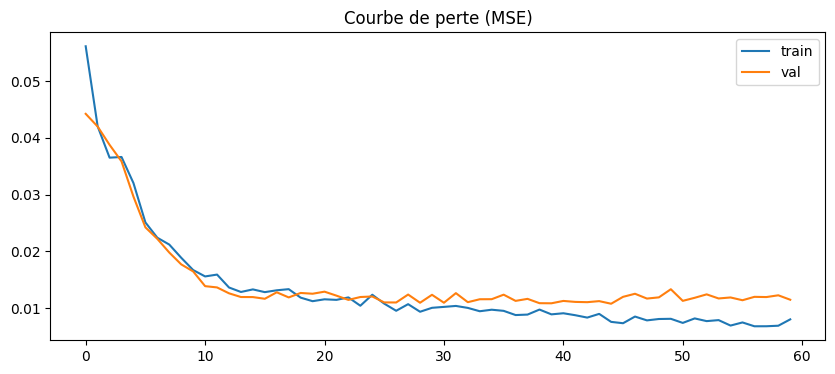

In [20]:
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Courbe de perte (MSE)'); plt.legend(); plt.show()

In [21]:
# Fonction pour re-transformer les predictions normalisees vers l'echelle reelle
def inverse_target(scaled_values, scaler, n_features, target_idx=0):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, target_idx] = scaled_values
    return scaler.inverse_transform(dummy)[:, target_idx]

y_pred_lstm_scaled = model.predict(X_test).flatten()
y_pred_lstm = inverse_target(y_pred_lstm_scaled, scaler, len(FEATURES))
y_test_real = inverse_target(y_test, scaler, len(FEATURES))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


## 6. Comparaison avec d'autres modeles
Meme decoupage temporel, memes cibles reelles, pour une comparaison equitable.

In [22]:
# Baseline naive : prediction(t) = valeur reelle(t-1)
# on reconstruit sur les memes index que test_df pour rester coherent avec le decoupage
test_target_series = test_df['passagers'].iloc[WINDOW_SIZE:]
baseline_pred = test_df['passagers'].shift(1).iloc[WINDOW_SIZE:].values

# Random Forest sur les memes features tabulaires (pas de sequence, juste la ligne de features)
X_train_tab = train_df[FEATURES].iloc[:-1]
y_train_tab = train_df['passagers'].shift(-1).dropna()
X_train_tab = X_train_tab.iloc[:len(y_train_tab)]

X_test_tab = test_df[FEATURES].iloc[WINDOW_SIZE:]

rf = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=SEED)
rf.fit(X_train_tab, y_train_tab)
y_pred_rf = rf.predict(X_test_tab)

### 6.1 Modele statistique classique : Holt-Winters
Ce modele est univarie (il ne regarde que la serie `passagers`, pas les features) et est entraine uniquement sur les donnees d'avant le test (train + val), puis projete sur le meme horizon que les autres modeles.

In [23]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

historique_avant_test = pd.concat([train_df, val_df])['passagers']
horizon_test = len(test_target_series)

# Holt-Winters : lissage exponentiel avec tendance et saisonnalite hebdomadaire (m=7)
hw_model = ExponentialSmoothing(
    historique_avant_test, trend='add', seasonal='add', seasonal_periods=7
).fit()
y_pred_hw = hw_model.forecast(horizon_test).values

In [24]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true==0, 1, y_true))) * 100
    r2 = r2_score(y_true, y_pred)
    return {'Modele': name, 'MAE': mae, 'RMSE': rmse, 'WAPE (%)': wape, 'MAPE (%)': mape, 'R2': r2}



results = pd.DataFrame([
    evaluate(test_target_series.values, baseline_pred, 'Naif (t-1)'),
    evaluate(test_target_series.values, y_pred_hw, 'Holt-Winters'),
    evaluate(y_test_real, y_pred_rf, 'Random Forest'),
    evaluate(y_test_real, y_pred_lstm, 'LSTM'),
])
results.sort_values('RMSE')



,Modele,MAE,RMSE,WAPE (%),MAPE (%),R2
3,LSTM,725.829952,1274.779690,9.127848,66.858628,0.750223
0,Naif (t-1),1681.104762,2401.576641,21.141135,48.392961,0.113506
2,Random Forest,1747.166353,2535.458992,21.971908,55.207022,0.011911
1,Holt-Winters,2911.715188,3640.986561,36.616970,117.689471,-1.037610


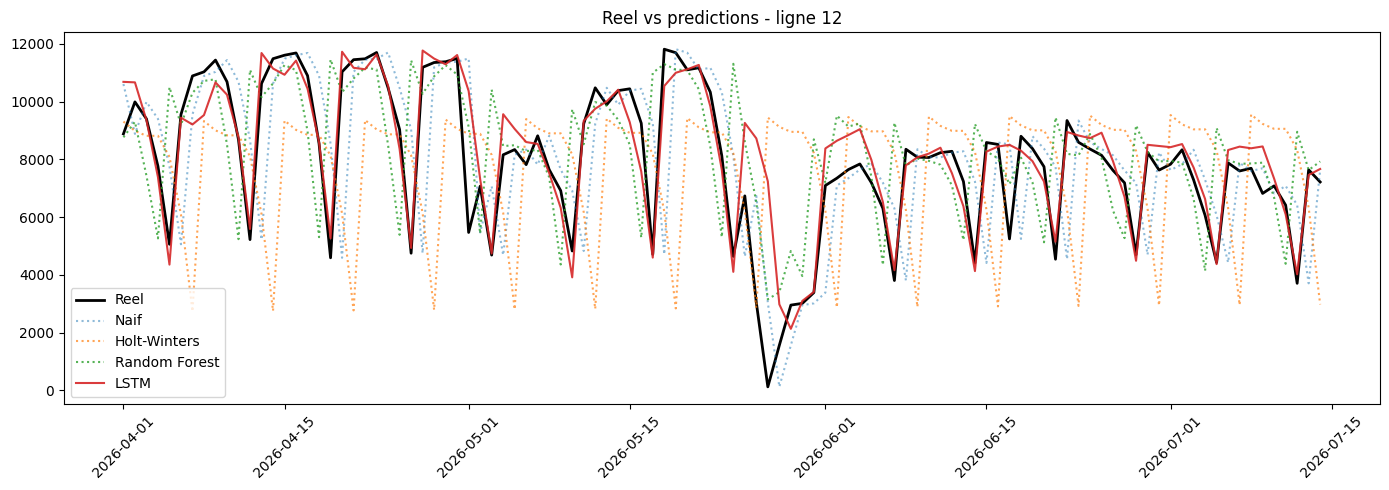

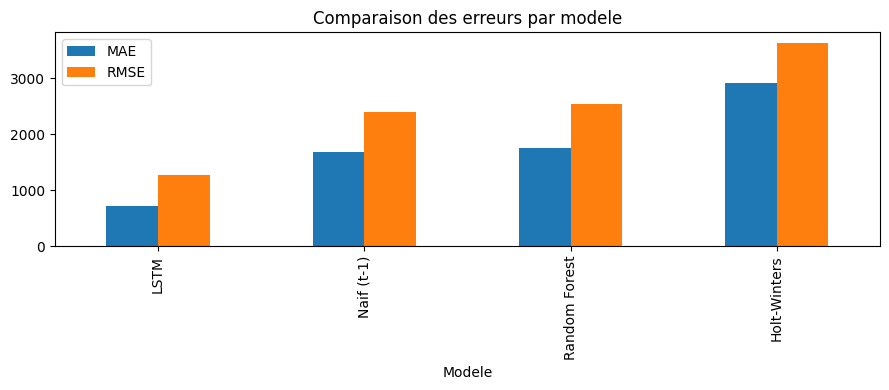

In [25]:
plt.figure(figsize=(14,5))
plt.plot(test_target_series.index, test_target_series.values, label='Reel', linewidth=2, color='black')
plt.plot(test_target_series.index, baseline_pred, label='Naif', alpha=0.5, linestyle=':')
plt.plot(test_target_series.index, y_pred_hw, label='Holt-Winters', alpha=0.7, linestyle=':')
plt.plot(test_target_series.index, y_pred_rf, label='Random Forest', alpha=0.8, linestyle=':')
plt.plot(test_target_series.index, y_pred_lstm, label='LSTM', alpha=0.9)
plt.title(f'Reel vs predictions - ligne {LIGNE_REFERENCE}')
plt.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

results.set_index('Modele')[['MAE','RMSE']].sort_values('RMSE').plot(
    kind='bar', figsize=(9,4), title='Comparaison des erreurs par modele')
plt.tight_layout(); plt.show()

## 7. Estimation du nombre de bus necessaires
Attention : `passagers` est un total JOURNALIER qui inclut tous les trajets de la journee (aller + retour, plusieurs rotations).

In [26]:
def arrondir_au_demi(x):
    # un bus ne peut etre affecte que par pas de 0.5 (une demi-periode = matin ou soir) ;
    # utilise uniquement pour arrondir la sortie brute du LSTM a une valeur operationnellement
    # realiste, plus pour un calcul de capacite
    return np.round(x * 2) / 2

def post_traiter_bus(bus_brut, nb_passagers):
    """Arrondit la prediction brute du LSTM-bus a un multiple de 0.5, avec un minimum de 1
    bus des qu'il y a du trafic (une ligne meme peu frequentee tourne matin ET soir)."""
    if nb_passagers <= 0:
        return 0.0
    return max(arrondir_au_demi(bus_brut), 1.0)

### Entrainement du LSTM-bus sur la ligne de reference

In [27]:
# FEATURES_BUS : memes features que le LSTM passagers + l'historique des bus (la cible)
FEATURES_BUS = FEATURES + ['bus']
IDX_BUS = len(FEATURES)   # position de la colonne 'bus' (ajoutee en dernier)

scaler_bus = MinMaxScaler()
scaler_bus.fit(train_df[FEATURES_BUS])

train_bus_s = scaler_bus.transform(train_df[FEATURES_BUS])
val_bus_s   = scaler_bus.transform(val_df[FEATURES_BUS])
test_bus_s  = scaler_bus.transform(test_df[FEATURES_BUS])

X_train_bus, y_train_bus = create_sequences(train_bus_s, WINDOW_SIZE, target_col_idx=IDX_BUS)
X_val_bus,   y_val_bus   = create_sequences(val_bus_s,   WINDOW_SIZE, target_col_idx=IDX_BUS)
X_test_bus,  y_test_bus  = create_sequences(test_bus_s,  WINDOW_SIZE, target_col_idx=IDX_BUS)

model_bus = construire_modele(len(FEATURES_BUS), WINDOW_SIZE, MEILLEURS_HP)
model_bus.fit(
    X_train_bus, y_train_bus, validation_data=(X_val_bus, y_val_bus),
    epochs=150, batch_size=MEILLEUR_BATCH_SIZE, verbose=0,
    callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)]
)

y_pred_bus_scaled = model_bus.predict(X_test_bus, verbose=0).flatten()
y_pred_bus_brut = inverse_target(y_pred_bus_scaled, scaler_bus, len(FEATURES_BUS), target_idx=IDX_BUS)
y_true_bus = inverse_target(y_test_bus, scaler_bus, len(FEATURES_BUS), target_idx=IDX_BUS)
y_test_passagers_reels = test_df['passagers'].iloc[WINDOW_SIZE:].values

y_pred_bus = np.array([
    post_traiter_bus(b, p) for b, p in zip(y_pred_bus_brut, y_test_passagers_reels)
])

model_bus.save(f'{MODELS_DIR}/lstm_bus_ligne{LIGNE_REFERENCE}.keras')
joblib.dump(scaler_bus, f'{MODELS_DIR}/scaler_bus_ligne{LIGNE_REFERENCE}.pkl')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


['/content/drive/MyDrive/alsa_pfa_corrige/models/scaler_bus_ligne12.pkl']

In [28]:
# 1) Les donnees d'entrainement du LSTM-bus contenaient-elles deja des NaN une fois mises a l'echelle ?
print("NaN dans train_df[FEATURES_BUS] :", train_df[FEATURES_BUS].isna().sum().sum())
print("NaN apres scaler_bus.transform(train) :", np.isnan(scaler_bus.transform(train_df[FEATURES_BUS])).sum())

# 2) Le modele lui-meme renvoie-t-il du NaN, meme sur une entree "propre" (donnees de test, pas de recursif) ?
test_check = scaler_bus.transform(test_df[FEATURES_BUS].iloc[:WINDOW_SIZE])[np.newaxis, :, :]
pred_check = model_bus.predict(test_check, verbose=0)
print("Le modele bus renvoie du NaN sur une entree normale :", np.isnan(pred_check).any())

# 3) L'historique d'entrainement du modele a-t-il diverge (loss NaN a un moment) ?
try:
    pertes = history_bus.history['loss']
    print("Loss contient du NaN pendant l'entrainement :", any(np.isnan(pertes)))
    print("Dernieres valeurs de loss :", pertes[-5:])
except NameError:
    print("Variable 'history_bus' introuvable")

NaN dans train_df[FEATURES_BUS] : 0
NaN apres scaler_bus.transform(train) : 0
Le modele bus renvoie du NaN sur une entree normale : False
Variable 'history_bus' introuvable


Ligne 12 - LSTM-bus : MAE=0.80, RMSE=1.38, R2=0.62


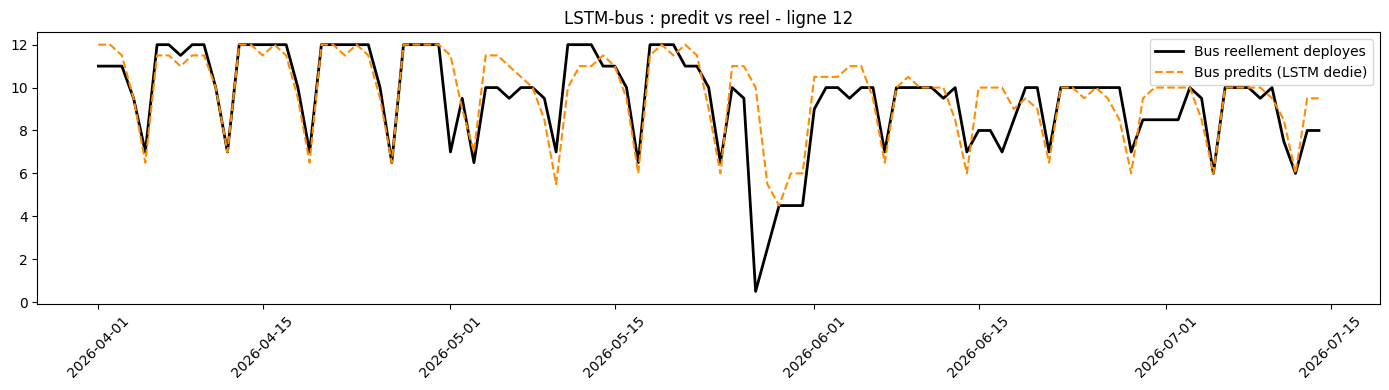

Ecart moyen (predit - deploye) : 0.27 bus. Positif = le modele recommande plus de bus que ce qui est actuellement deploye.


In [29]:
dates_test = test_df.index[WINDOW_SIZE:]
bus_reellement_deployes = test_df['bus'].iloc[WINDOW_SIZE:].values

resultat_bus_lstm = evaluate(bus_reellement_deployes, y_pred_bus, 'LSTM-bus')
print(f"Ligne {LIGNE_REFERENCE} - LSTM-bus : MAE={resultat_bus_lstm['MAE']:.2f}, "
      f"RMSE={resultat_bus_lstm['RMSE']:.2f}, R2={resultat_bus_lstm['R2']:.2f}")

plt.figure(figsize=(14,4))
plt.plot(dates_test, bus_reellement_deployes, label='Bus reellement deployes', linewidth=2, color='black')
plt.plot(dates_test, y_pred_bus, label='Bus predits (LSTM dedie)', linestyle='--', color='darkorange')
plt.title(f'LSTM-bus : predit vs reel - ligne {LIGNE_REFERENCE}')
plt.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

ecart_moyen = float(np.mean(y_pred_bus - bus_reellement_deployes))
print(f"Ecart moyen (predit - deploye) : {ecart_moyen:.2f} bus. "
      f"Positif = le modele recommande plus de bus que ce qui est actuellement deploye.")

### Prevision sur un intervalle de dates choisi
Au-dela de la periode de test, on peut demander une prevision pour n'importe quelle date future (ou un intervalle de dates), exactement comme le fera l'API. Le nombre de bus est maintenant produit **directement par le LSTM-bus**, en deux temps a chaque jour : d'abord le LSTM passagers predit la frequentation du jour, puis le LSTM-bus predit le nombre de bus necessaire a partir du contexte (dont la frequentation qui vient d'etre predite).

In [30]:
def previsions_intervalle(ligne, modele_passagers, scaler_passagers, modele_bus, scaler_bus,
                           date_debut, date_fin):
    """Prevoit jour par jour, du dernier jour connu jusqu'a date_fin, puis ne renvoie que
    les jours compris entre date_debut et date_fin (intervalle demande par l'utilisateur).
    A chaque jour : (1) le LSTM passagers predit la frequentation, (2) le LSTM-bus predit
    le nombre de bus, EN UTILISANT LA MEME FENETRE (les 30 jours AVANT le jour a predire,
    jamais le jour lui-meme - coherent avec la facon dont les deux modeles ont ete
    entraines). Pour un jour declare/connu comme Aid, la prevision brute des passagers est
    recalee sur le facteur de baisse historiquement observe (voir calculer_facteur_aid)."""
    historique = preparer_serie(df, ligne)
    type_l = historique['type_ligne'].mode()[0]
    derniere_date = historique.index[-1]
    horizon = (pd.Timestamp(date_fin) - derniere_date).days
    if horizon < 1:
        raise ValueError(f"date_fin doit etre posterieure a {derniere_date.date()}")

    facteur_aid = calculer_facteur_aid(add_features(historique))

    chemin = []
    for _ in range(horizon):
        # IMPORTANT : on construit la fenetre AVANT d'ajouter le jour a predire.
        # Les deux modeles utilisent la MEME fenetre (30 jours precedents, jamais NaN).
        feat = add_features(historique)
        prochaine_date = historique.index[-1] + pd.Timedelta(days=1)

        # --- etape 1 : prevision des passagers ---
        fenetre_p = feat[FEATURES].iloc[-WINDOW_SIZE:]
        Xp = scaler_passagers.transform(fenetre_p)[np.newaxis, :, :]
        yp_scaled = modele_passagers.predict(Xp, verbose=0).flatten()[0]
        p = inverse_target(np.array([yp_scaled]), scaler_passagers, len(FEATURES))[0]

        if str(ligne) == '73' and prochaine_date.month in (7, 8):
            p = 0.0
        elif est_jour_aid(prochaine_date) and facteur_aid is not None:
            baseline_normale = feat['rolling_mean_30'].iloc[-1]
            p = baseline_normale * facteur_aid

        # un nombre de passagers est un entier positif : jamais negatif, jamais a virgule
        p = max(0, round(p))

        # --- etape 2 : prevision du nombre de bus (meme fenetre 'feat', pas de NaN) ---
        fenetre_b = feat[FEATURES_BUS].iloc[-WINDOW_SIZE:]
        Xb = scaler_bus.transform(fenetre_b)[np.newaxis, :, :]
        yb_scaled = modele_bus.predict(Xb, verbose=0).flatten()[0]
        b_brut = inverse_target(np.array([yb_scaled]), scaler_bus, len(FEATURES_BUS), target_idx=IDX_BUS)[0]
        b = 0.0 if str(ligne) == '73' and prochaine_date.month in (7, 8) else post_traiter_bus(b_brut, p)

        chemin.append({'date': prochaine_date, 'passagers_predits': p, 'bus_recommandes': b})

        # on ajoute la ligne COMPLETE (passagers + bus) en une seule fois, une fois les
        # deux predictions faites - jamais de NaN insere dans l'historique
        historique.loc[prochaine_date] = {
            'passagers': p, 'bus': b, 'type_jour': 'LV', 'type_ligne': type_l
        }

    resultat = pd.DataFrame(chemin).set_index('date')
    return resultat.loc[date_debut:date_fin]

In [31]:
# Exemple : prevision sur un intervalle de 2 semaines, a adapter
DATE_DEBUT_EXEMPLE = (df['date'].max() + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
DATE_FIN_EXEMPLE = (df['date'].max() + pd.Timedelta(days=14)).strftime('%Y-%m-%d')

previsions_periode = previsions_intervalle(
    LIGNE_REFERENCE, model, scaler, model_bus, scaler_bus,
    DATE_DEBUT_EXEMPLE, DATE_FIN_EXEMPLE
)
previsions_periode

,passagers_predits,bus_recommandes
date,,
2026-07-15,7653,9.5
2026-07-16,7782,9.5
2026-07-17,7007,9.5
2026-07-18,5958,8.0
2026-07-19,3903,5.5
2026-07-20,7192,9.0
2026-07-21,7366,9.5
2026-07-22,7400,9.5
2026-07-23,7562,9.5


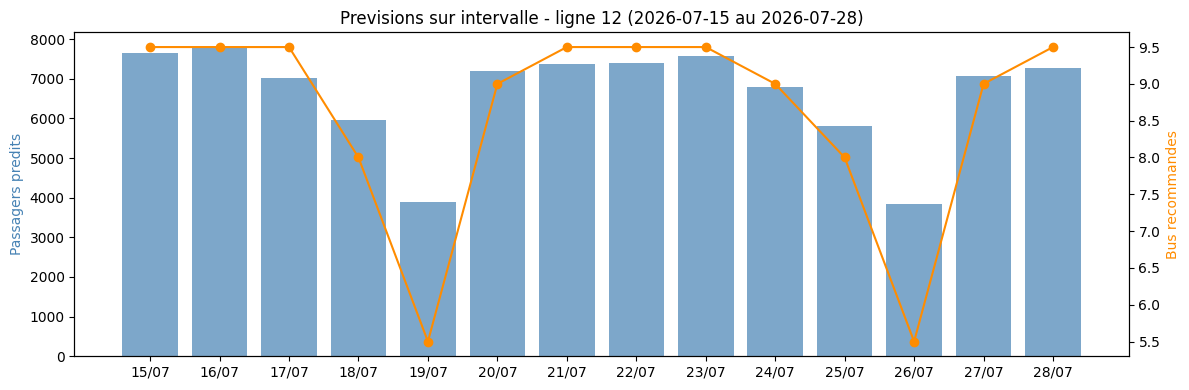

In [32]:
fig, ax1 = plt.subplots(figsize=(12,4))
ax1.bar(previsions_periode.index.strftime('%d/%m'), previsions_periode['passagers_predits'], color='steelblue', alpha=0.7)
ax1.set_ylabel('Passagers predits', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(previsions_periode.index.strftime('%d/%m'), previsions_periode['bus_recommandes'], color='darkorange', marker='o')
ax2.set_ylabel('Bus recommandes', color='darkorange')
plt.title(f'Previsions sur intervalle - ligne {LIGNE_REFERENCE} ({DATE_DEBUT_EXEMPLE} au {DATE_FIN_EXEMPLE})')
plt.tight_layout(); plt.show()

## 8. Application du LSTM a TOUTES les lignes actives
On applique directement le LSTM (avec les hyperparametres trouves par Optuna sur la ligne de reference) a chacune des lignes actives. La comparaison avec les autres modeles (Random Forest, Holt-Winters) reste reservee a la ligne de reference (section 6) ; ici, l'objectif est d'obtenir un modele de prevision et une estimation de bus pour chaque ligne.

Le nombre d'epochs est reduit pour que la boucle reste raisonnable sur toutes les lignes ; vous pourrez reentrainer plus longuement une ligne precise en reprenant les sections 3 a 5 avec `LIGNE_REFERENCE` = la ligne choisie.

In [33]:
# preparer_serie est deja definie section 1 ; reutilisee ici pour toutes les lignes
def preparer_sequences(data_feat, window_size, features):
    n = len(data_feat)
    train_end = int(n*0.70)
    val_end   = int(n*0.85)
    train_df = data_feat.iloc[:train_end]
    val_df   = data_feat.iloc[train_end:val_end]
    test_df  = data_feat.iloc[val_end:]

    scaler = MinMaxScaler()
    scaler.fit(train_df[features])

    train_s = scaler.transform(train_df[features])
    val_s   = scaler.transform(val_df[features])
    test_s  = scaler.transform(test_df[features])

    X_train, y_train = create_sequences(train_s, window_size)
    X_val,   y_val   = create_sequences(val_s, window_size)
    X_test,  y_test  = create_sequences(test_s, window_size)
    return (X_train, y_train, X_val, y_val, X_test, y_test,
            scaler, train_df, val_df, test_df)

def entrainer_lstm_ligne(X_train, y_train, X_val, y_val, n_features, window_size,
                          ligne, models_dir, hp, batch_size, epochs=60, patience=8,
                          prefixe='lstm_ligne'):
    """Entraineur generique : sert autant pour le LSTM passagers (prefixe='lstm_ligne')
    que pour le LSTM-bus (prefixe='lstm_bus_ligne')."""
    m = construire_modele(n_features, window_size, hp)
    safe_name = str(ligne).replace(' ', '_').replace('/', '_')
    cb = [
        EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True),
        ModelCheckpoint(f'{models_dir}/{prefixe}_{safe_name}.keras', save_best_only=True)
    ]
    m.fit(X_train, y_train, validation_data=(X_val, y_val),
          epochs=epochs, batch_size=batch_size, callbacks=cb, verbose=0)
    return m

In [34]:
# Boucle principale sur toutes les lignes actives : LSTM passagers + LSTM-bus dedie
MIN_JOURS = WINDOW_SIZE * 4   # une ligne trop peu active (ex. navette speciale) est ignoree
toutes_les_lignes = sorted(df['ligne'].unique())
resultats_globaux = []
echecs = []

for ligne in toutes_les_lignes:
    try:
        serie_l = preparer_serie(df, ligne)
        if len(serie_l) < MIN_JOURS:
            echecs.append((ligne, 'historique trop court'))
            continue

        feat_l = add_features(serie_l)
        if len(feat_l) < MIN_JOURS:
            echecs.append((ligne, 'trop peu de donnees apres feature engineering'))
            continue

        # --- LSTM passagers ---
        (X_tr, y_tr, X_va, y_va, X_te, y_te,
         scaler_l, train_df_l, val_df_l, test_df_l) = preparer_sequences(feat_l, WINDOW_SIZE, FEATURES)

        if len(X_te) == 0 or len(X_tr) == 0:
            echecs.append((ligne, 'sequences insuffisantes pour le split train/val/test'))
            continue

        model_l = entrainer_lstm_ligne(X_tr, y_tr, X_va, y_va, len(FEATURES), WINDOW_SIZE,
                                        ligne, MODELS_DIR, MEILLEURS_HP, MEILLEUR_BATCH_SIZE,
                                        prefixe='lstm_ligne')
        safe_name = str(ligne).replace(' ', '_').replace('/', '_')
        joblib.dump(scaler_l, f'{MODELS_DIR}/scaler_ligne_{safe_name}.pkl')

        y_pred_lstm_l = inverse_target(model_l.predict(X_te, verbose=0).flatten(), scaler_l, len(FEATURES))
        y_true_l = inverse_target(y_te, scaler_l, len(FEATURES))
        r_lstm = evaluate(y_true_l, y_pred_lstm_l, 'LSTM')

        # --- LSTM-bus dedie (meme principe, cible = 'bus') ---
        FEATURES_BUS_l = FEATURES + ['bus']
        idx_bus_l = len(FEATURES)
        scaler_bus_l = MinMaxScaler()
        scaler_bus_l.fit(train_df_l[FEATURES_BUS_l])
        train_bus_s_l = scaler_bus_l.transform(train_df_l[FEATURES_BUS_l])
        val_bus_s_l   = scaler_bus_l.transform(val_df_l[FEATURES_BUS_l])
        test_bus_s_l  = scaler_bus_l.transform(test_df_l[FEATURES_BUS_l])

        X_tr_b, y_tr_b = create_sequences(train_bus_s_l, WINDOW_SIZE, target_col_idx=idx_bus_l)
        X_va_b, y_va_b = create_sequences(val_bus_s_l,   WINDOW_SIZE, target_col_idx=idx_bus_l)
        X_te_b, y_te_b = create_sequences(test_bus_s_l,  WINDOW_SIZE, target_col_idx=idx_bus_l)

        model_bus_l = entrainer_lstm_ligne(X_tr_b, y_tr_b, X_va_b, y_va_b, len(FEATURES_BUS_l), WINDOW_SIZE,
                                            ligne, MODELS_DIR, MEILLEURS_HP, MEILLEUR_BATCH_SIZE,
                                            prefixe='lstm_bus_ligne')
        joblib.dump(scaler_bus_l, f'{MODELS_DIR}/scaler_bus_ligne_{safe_name}.pkl')

        y_pred_bus_brut_l = inverse_target(model_bus_l.predict(X_te_b, verbose=0).flatten(),
                                            scaler_bus_l, len(FEATURES_BUS_l), target_idx=idx_bus_l)
        y_true_bus_l = inverse_target(y_te_b, scaler_bus_l, len(FEATURES_BUS_l), target_idx=idx_bus_l)
        y_passagers_reels_l = test_df_l['passagers'].iloc[WINDOW_SIZE:].values
        bus_recommandes_l = np.array([
            post_traiter_bus(b, p) for b, p in zip(y_pred_bus_brut_l, y_passagers_reels_l)
        ])
        r_bus = evaluate(y_true_bus_l, bus_recommandes_l, 'LSTM-bus')
        bus_deployes_l = test_df_l['bus'].iloc[WINDOW_SIZE:].values
        ecart_bus_moyen_l = float(np.mean(bus_recommandes_l - bus_deployes_l))

        resultats_globaux.append({
            'ligne': ligne,
            'type_ligne': test_df_l['type_ligne'].mode()[0],
            'nb_jours': len(feat_l),
            'MAE_lstm': r_lstm['MAE'], 'RMSE_lstm': r_lstm['RMSE'],
            'MAPE_lstm': r_lstm['MAPE (%)'], 'R2_lstm': r_lstm['R2'],
            'MAE_bus': r_bus['MAE'], 'RMSE_bus': r_bus['RMSE'],
            'ecart_bus_moyen': ecart_bus_moyen_l
        })
        print(f'Ligne {ligne} : OK (RMSE passagers = {r_lstm["RMSE"]:.1f}, RMSE bus = {r_bus["RMSE"]:.2f})')

    except Exception as e:
        echecs.append((ligne, str(e)))
        print(f'Ligne {ligne} : ECHEC -> {e}')

print('\nTermine.', len(resultats_globaux), 'lignes traitees avec succes,', len(echecs), 'echecs.')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Ligne 1 : OK (RMSE passagers = 148.1, RMSE bus = 0.79)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Ligne 10 : OK (RMSE passagers = 86.9, RMSE bus = 0.00)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

Ligne 98 : OK (RMSE passagers = 860.9, RMSE bus = 0.65)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/tmp/ipykernel_841477/3900347737.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/tmp/ipykernel_841477/3900347737.py:4: RuntimeWarning: invalid value encountered in scalar divide
  wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: D

Ligne 99 : OK (RMSE passagers = 69.5, RMSE bus = 0.00)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Ligne AE : OK (RMSE passagers = 35.5, RMSE bus = 0.00)

Termine. 38 lignes traitees avec succes, 0 echecs.


In [35]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [36]:
synthese = pd.DataFrame(resultats_globaux).sort_values('RMSE_lstm')
print('Lignes en echec :', echecs)
synthese

Lignes en echec : []


,ligne,type_ligne,nb_jours,MAE_lstm,RMSE_lstm,MAPE_lstm,R2_lstm,MAE_bus,RMSE_bus,ecart_bus_moyen
37,AE,REG,896,28.076029,35.516600,34.191328,-0.341538,0.000000,0.000000,0.000000
32,9,URB,896,20.052373,36.089618,1391.148510,-0.068864,0.085714,0.292770,0.085714
6,15,URB,896,52.850860,69.385617,1388.385584,0.469033,0.000000,0.000000,0.000000
36,99,URB,896,55.643895,69.454367,5564.389544,0.000000,0.000000,0.000000,0.000000
5,14,URB,896,57.364509,80.649323,446.169473,0.137117,0.000000,0.000000,0.000000
1,10,URB,896,62.651120,86.917062,3108.387509,0.082132,0.000000,0.000000,0.000000
21,37,REG,896,48.398697,87.175657,1195.325557,0.661721,0.057143,0.239046,0.057143
4,13,URB,896,64.331141,98.212112,542.123087,0.416497,0.023810,0.129099,0.023810
23,39,REG,896,70.593640,108.441555,2514.682016,0.707003,0.000000,0.000000,0.000000
12,24,URB,896,84.728338,118.952218,58.393897,0.131364,0.109524,0.234013,0.023810


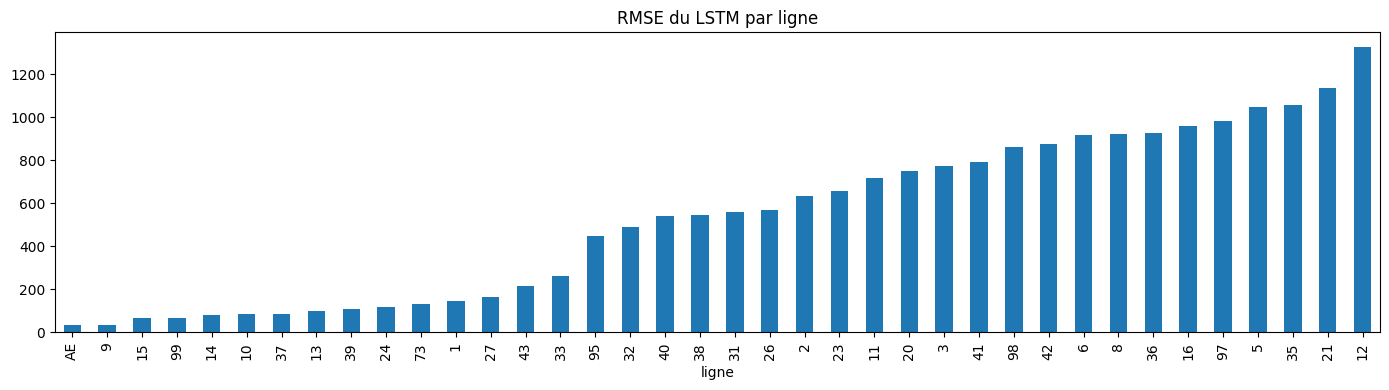

In [37]:
# Sauvegarde du tableau de synthese pour le rapport
REPORTS_DIR = '/content/drive/MyDrive/alsa_pfa_corrige/reports'
os.makedirs(REPORTS_DIR, exist_ok=True)
synthese.to_csv(f'{REPORTS_DIR}/synthese_metriques_par_ligne.csv', index=False)

# Distribution du RMSE selon les lignes, pour reperer visuellement les lignes bien/mal predites
synthese.set_index('ligne')['RMSE_lstm'].sort_values().plot(
    kind='bar', figsize=(14,4), title='RMSE du LSTM par ligne')
plt.tight_layout(); plt.show()

Pour cette generation de previsions a 3 mois, on utilise les modeles par ligne (section 8) par defaut : plus simples a operer un par un, et le modele le plus specialise pour chaque ligne. Si comparaison_approches montre qu'une ligne precise est nettement mieux predite par le modele global, vous pouvez adapter la fonction ci-dessous pour cette ligne.

Attention a l'horizon de 3 mois : la prevision est recursive (chaque jour predit sert a calculer le suivant), donc l'erreur s'accumule avec le temps - la fiabilite a 90 jours est mecaniquement plus faible qu'a 7 ou 15 jours. C'est justement pour ca qu'on sauvegarde ces previsions maintenant : en comparant avec la realite au fur et a mesure (semaine par semaine), vous pourrez mesurer concretement a partir de quel horizon le modele derive, et recommander un rythme de re-entrainement a ALSA (ex. mensuel) plutot que de se fier aveuglement a 90 jours d'un coup.



In [38]:
HORIZON_3_MOIS = 90   # environ 3 mois

def previsions_3_mois_ligne(ligne, horizon=HORIZON_3_MOIS):
    safe_name = str(ligne).replace(' ', '_').replace('/', '_')
    modele_p = load_model(f'{MODELS_DIR}/lstm_ligne_{safe_name}.keras')
    scaler_p = joblib.load(f'{MODELS_DIR}/scaler_ligne_{safe_name}.pkl')
    modele_b = load_model(f'{MODELS_DIR}/lstm_bus_ligne_{safe_name}.keras')
    scaler_b = joblib.load(f'{MODELS_DIR}/scaler_bus_ligne_{safe_name}.pkl')

    historique = preparer_serie(df, ligne)
    date_debut = historique.index[-1] + pd.Timedelta(days=1)
    date_fin = historique.index[-1] + pd.Timedelta(days=horizon)

    resultat = previsions_intervalle(
        ligne, modele_p, scaler_p, modele_b, scaler_b,
        date_debut.strftime('%Y-%m-%d'), date_fin.strftime('%Y-%m-%d')
    )
    resultat = resultat.reset_index().rename(columns={'index': 'date'})
    resultat['ligne'] = ligne
    resultat['date_generation'] = pd.Timestamp.today().normalize()
    return resultat

In [39]:
# Generation pour toutes les lignes ayant un modele entraine (section 8)
toutes_previsions_3_mois = []
for ligne in toutes_les_lignes:
    safe_name = str(ligne).replace(' ', '_').replace('/', '_')
    chemin_modele_p = f'{MODELS_DIR}/lstm_ligne_{safe_name}.keras'
    chemin_modele_b = f'{MODELS_DIR}/lstm_bus_ligne_{safe_name}.keras'
    if not (os.path.exists(chemin_modele_p) and os.path.exists(chemin_modele_b)):
        print(f'Ligne {ligne} : modele(s) manquant(s) (passagers et/ou bus), ignoree.')
        continue
    try:
        prev = previsions_3_mois_ligne(ligne)
        toutes_previsions_3_mois.append(prev)
        print(f'Ligne {ligne} : prevision generee ({len(prev)} jours)')
    except Exception as e:
        print(f'Ligne {ligne} : echec -> {e}')

previsions_3_mois_df = pd.concat(toutes_previsions_3_mois, ignore_index=True)
previsions_3_mois_df = previsions_3_mois_df[
    ['date', 'ligne', 'passagers_predits', 'bus_recommandes', 'date_generation']
]
previsions_3_mois_df

Ligne 1 : prevision generee (90 jours)
Ligne 10 : prevision generee (90 jours)
Ligne 11 : prevision generee (90 jours)
Ligne 12 : prevision generee (90 jours)
Ligne 13 : prevision generee (90 jours)
Ligne 14 : prevision generee (90 jours)
Ligne 15 : prevision generee (90 jours)
Ligne 16 : prevision generee (90 jours)
Ligne 2 : prevision generee (90 jours)
Ligne 20 : prevision generee (90 jours)
Ligne 21 : prevision generee (90 jours)
Ligne 23 : prevision generee (90 jours)
Ligne 24 : prevision generee (90 jours)
Ligne 26 : prevision generee (90 jours)
Ligne 27 : prevision generee (90 jours)
Ligne 3 : prevision generee (90 jours)
Ligne 31 : prevision generee (90 jours)
Ligne 32 : prevision generee (90 jours)
Ligne 33 : prevision generee (90 jours)
Ligne 35 : prevision generee (90 jours)
Ligne 36 : prevision generee (90 jours)
Ligne 37 : prevision generee (90 jours)
Ligne 38 : prevision generee (90 jours)
Ligne 39 : prevision generee (90 jours)
Ligne 40 : prevision generee (90 jours)
Lig

,date,ligne,passagers_predits,bus_recommandes,date_generation
0,2026-07-15,1,570,1.5,2026-08-16
1,2026-07-16,1,568,1.5,2026-08-16
2,2026-07-17,1,523,1.5,2026-08-16
3,2026-07-18,1,255,1.0,2026-08-16
4,2026-07-19,1,0,0.0,2026-08-16
...,...,...,...,...,...
3415,2026-10-08,AE,155,3.0,2026-08-16
3416,2026-10-09,AE,157,3.0,2026-08-16
3417,2026-10-10,AE,159,3.0,2026-08-16
3418,2026-10-11,AE,161,3.0,2026-08-16


In [40]:
# Sauvegarde en CSV et Excel, horodatee (utile pour suivre plusieurs generations de previsions dans le temps)
horodatage = pd.Timestamp.today().strftime('%Y%m%d')
chemin_csv = f'{REPORTS_DIR}/previsions_3_mois_{horodatage}.csv'
chemin_xlsx = f'{REPORTS_DIR}/previsions_3_mois_{horodatage}.xlsx'

previsions_3_mois_df.to_csv(chemin_csv, index=False)
previsions_3_mois_df.to_excel(chemin_xlsx, index=False)

print('Previsions sauvegardees :')
print(' -', chemin_csv)
print(' -', chemin_xlsx)

Previsions sauvegardees :
 - /content/drive/MyDrive/alsa_pfa_corrige/reports/previsions_3_mois_20260816.csv
 - /content/drive/MyDrive/alsa_pfa_corrige/reports/previsions_3_mois_20260816.xlsx


## 13. Suivi previsions vs realite (log CSV)
Pour verifier dans le temps la fiabilite du modele sur les 3 prochains mois, on enregistre chaque prevision faite (date, ligne, valeur predite) dans un fichier CSV. Une fois les jours ecoules, on compare avec les vraies valeurs et on calcule l'erreur reelle - a refaire regulierement (ex. chaque semaine) pour suivre si le modele reste fiable ou s'il faut le reentrainer.

In [41]:
LOG_PATH = '/content/drive/MyDrive/alsa_pfa_corrige/reports/previsions_log.csv'

def enregistrer_previsions(ligne, previsions_df, log_path=LOG_PATH):
    """Ajoute des previsions au log CSV, avec la date a laquelle la prevision a ete faite
    (utile pour comparer plus tard plusieurs previsions faites a des moments differents
    pour la meme date cible)."""
    nouveau = previsions_df.reset_index().rename(columns={'index': 'date_cible', 'date': 'date_cible'})
    nouveau['ligne'] = ligne
    nouveau['date_cible'] = pd.to_datetime(nouveau['date_cible']).dt.strftime('%Y-%m-%d')
    nouveau['date_prevision_faite'] = pd.Timestamp.today().strftime('%Y-%m-%d')
    nouveau = nouveau[['date_prevision_faite', 'ligne', 'date_cible', 'passagers_predits', 'bus_recommandes']]

    if os.path.exists(log_path):
        ancien = pd.read_csv(log_path)
        log = pd.concat([ancien, nouveau], ignore_index=True)
    else:
        log = nouveau
    log.to_csv(log_path, index=False)
    print(f'{len(nouveau)} previsions enregistrees dans {log_path}')
    return log

# Exemple : on enregistre les previsions calculees en section 7.3 (previsions_periode)
log_previsions = enregistrer_previsions(LIGNE_REFERENCE, previsions_periode)

14 previsions enregistrees dans /content/drive/MyDrive/alsa_pfa_corrige/reports/previsions_log.csv


In [42]:
def comparer_previsions_realite(log_path=LOG_PATH, df_reel=df):
    """Rapproche chaque prevision enregistree de la vraie valeur, pour les dates deja passees.
    A relancer regulierement (ex. chaque semaine) pour suivre la precision reelle du modele."""
    if not os.path.exists(log_path):
        print('Aucun log de prevision trouve pour le moment.')
        return None

    log = pd.read_csv(log_path, parse_dates=['date_cible'])
    reel = df_reel[['date', 'ligne', 'passagers', 'bus']].rename(
        columns={'date': 'date_cible', 'passagers': 'passagers_reels', 'bus': 'bus_reels'})
    reel['ligne'] = reel['ligne'].astype(str)
    log['ligne'] = log['ligne'].astype(str)

    comparaison = log.merge(reel, on=['date_cible', 'ligne'], how='inner')
    if len(comparaison) == 0:
        print('Aucune des dates previtues n\'est encore passee : rien a comparer pour le moment.')
        return comparaison

    comparaison['erreur_absolue'] = (comparaison['passagers_predits'] - comparaison['passagers_reels']).abs()
    comparaison['erreur_pct'] = (comparaison['erreur_absolue'] / comparaison['passagers_reels'].replace(0, 1)) * 100
    comparaison['ecart_bus'] = comparaison['bus_recommandes'] - comparaison['bus_reels']

    print('MAPE moyen sur les previsions verifiees :', round(comparaison['erreur_pct'].mean(), 1), '%')
    return comparaison.sort_values('date_cible')

comparaison_reelle = comparer_previsions_realite()
comparaison_reelle

Aucune des dates previtues n'est encore passee : rien a comparer pour le moment.


,date_prevision_faite,ligne,date_cible,passagers_predits,bus_recommandes,passagers_reels,bus_reels
